<style>
.rendered_html h1 { color: #1f4e79; }
.rendered_html h2 { color: #0f766e; }
.rendered_html h3, .rendered_html h4 { color: #7c3aed; }
</style>

# Data Preparation and Exploration

This notebook loads MovieLens 100K, explores the data, creates implicit feedback, builds train/test splits, and saves processed files for later notebooks.

## Setup

We import helper functions from `src/` so later notebooks can reuse the same preprocessing logic.

In [1]:
from pathlib import Path
import sys

import pandas as pd

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(project_root))

from src.data_utils import (
    add_index_columns,
    compute_sparsity,
    create_implicit_feedback,
    create_mappings,
    ensure_project_dirs,
    leave_one_out_split,
    load_movielens_100k,
    save_processed_data,
)
from src.plotting_utils import (
    plot_interactions_per_movie,
    plot_interactions_per_user,
    plot_rating_distribution,
)

ensure_project_dirs(project_root)

data_dir = project_root / "dataset" / "ml-100k"
processed_dir = project_root / "data" / "processed"

## Load MovieLens 100K

We load ratings, users, and movies from the original dataset files.

In [2]:
ratings, users, movies = load_movielens_100k(data_dir)

display(ratings.head())
display(users.head())
display(movies[["movie_id", "title", "release_date"]].head())

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


,movie_id,title,release_date
0,1,Toy Story (1995),01-Jan-1995
1,2,GoldenEye (1995),01-Jan-1995
2,3,Four Rooms (1995),01-Jan-1995
3,4,Get Shorty (1995),01-Jan-1995
4,5,Copycat (1995),01-Jan-1995


## Basic Exploration

We check shapes, missing values, and simple dataset counts.

In [3]:
print("Ratings shape:", ratings.shape)
print("Users shape:", users.shape)
print("Movies shape:", movies.shape)

missing_values = pd.DataFrame({
    "ratings_missing": ratings.isna().sum(),
    "users_missing": users.isna().sum(),
    "movies_missing": movies.isna().sum(),
})

display(missing_values)

num_users = users["user_id"].nunique()
num_movies = movies["movie_id"].nunique()
num_ratings = len(ratings)

print("Number of users:", num_users)
print("Number of movies:", num_movies)
print("Number of ratings:", num_ratings)
print("Rating distribution:")
display(ratings["rating"].value_counts().sort_index())

Ratings shape: (100000, 4)
Users shape: (943, 5)
Movies shape: (1682, 24)


,ratings_missing,users_missing,movies_missing
Action,NaN,NaN,0.0
Adventure,NaN,NaN,0.0
Animation,NaN,NaN,0.0
Children,NaN,NaN,0.0
Comedy,NaN,NaN,0.0
Crime,NaN,NaN,0.0
Documentary,NaN,NaN,0.0
Drama,NaN,NaN,0.0
Fantasy,NaN,NaN,0.0
Film-Noir,NaN,NaN,0.0


Number of users: 943
Number of movies: 1682
Number of ratings: 100000
Rating distribution:


rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64

## Initial Plots

These plots show how ratings and interactions are distributed.

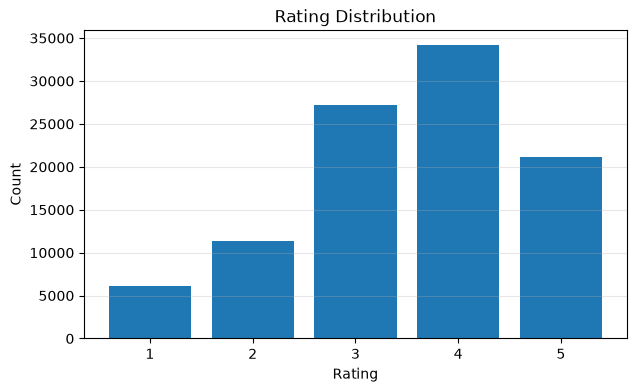

In [4]:
plot_rating_distribution(ratings)

## Explicit to Implicit Feedback

MovieLens is originally explicit feedback because users give ratings from 1 to 5. For an implicit recommendation system, we transform it into a liked/not-liked signal.

Here, `rating >= 4` means the user liked the movie, so `interaction = 1`.

In [5]:
ratings_implicit, positive_interactions = create_implicit_feedback(ratings, threshold=4)

print("All ratings:", len(ratings_implicit))
print("Positive interactions:", len(positive_interactions))

display(positive_interactions.head())

All ratings: 100000
Positive interactions: 55375


,user_id,movie_id,rating,timestamp,interaction
5,298,474,4,884182806,1
7,253,465,5,891628467,1
11,286,1014,5,879781125,1
12,200,222,5,876042340,1
16,122,387,5,879270459,1


## Positive Interaction Plots

We inspect how many positive interactions each user and movie has.

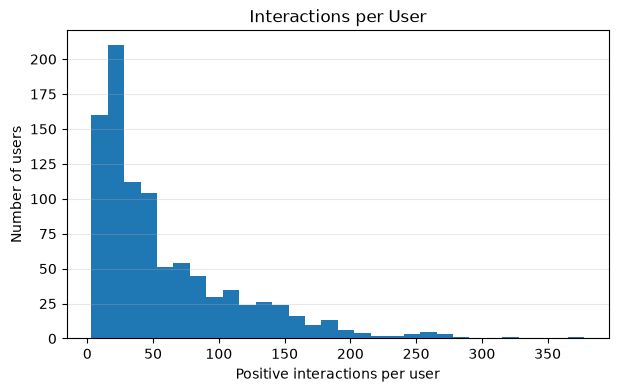

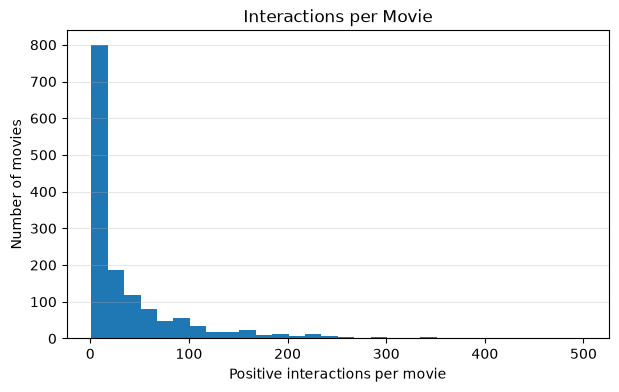

In [6]:
plot_interactions_per_user(positive_interactions)
plot_interactions_per_movie(positive_interactions)

## Sparsity

Recommender datasets are sparse because most users interact with only a small number of items. Sparsity measures how much of the full user-item matrix is empty.

In [7]:
sparsity = compute_sparsity(
    num_positive_interactions=len(positive_interactions),
    num_users=num_users,
    num_movies=num_movies,
)

print(f"Sparsity: {sparsity:.4%}")

Sparsity: 96.5088%


## Leave-One-Out Split

For each user, the model learns from previous positive interactions and is tested on the latest liked item.

If the test set has 942 users instead of the original 943 MovieLens users, that is expected: after converting ratings to implicit positives with `rating >= 4`, some users may have no positive interaction left, so they cannot contribute a held-out positive test item.


In [8]:
train_data, test_data = leave_one_out_split(positive_interactions)

print("Train interactions:", len(train_data))
print("Test interactions:", len(test_data))
print("Users in test data:", test_data["user_id"].nunique())

Train interactions: 54433
Test interactions: 942
Users in test data: 942


## Index Mappings

Models need continuous indexes starting from 0. We map original MovieLens ids to model-friendly indexes.

In [9]:
user_to_idx, movie_to_idx, idx_to_user, idx_to_movie = create_mappings(users, movies)

train_data = add_index_columns(train_data, user_to_idx, movie_to_idx)
test_data = add_index_columns(test_data, user_to_idx, movie_to_idx)
users_processed = users.copy()
users_processed["user_idx"] = users_processed["user_id"].map(user_to_idx)
movies_processed = movies.copy()
movies_processed["movie_idx"] = movies_processed["movie_id"].map(movie_to_idx)

display(train_data[["user_id", "user_idx", "movie_id", "movie_idx", "interaction"]].head())

,user_id,user_idx,movie_id,movie_idx,interaction
59972,1,0,168,167,1
92487,1,0,172,171,1
74577,1,0,165,164,1
48214,1,0,156,155,1
15764,1,0,196,195,1


## Save Processed Data

We save the processed train/test splits, movies, users, and metadata so later notebooks can reuse them directly.

In [10]:
metadata = {
    "user_to_idx": user_to_idx,
    "movie_to_idx": movie_to_idx,
    "idx_to_user": idx_to_user,
    "idx_to_movie": idx_to_movie,
    "num_users": num_users,
    "num_movies": num_movies,
    "sparsity": sparsity,
}

save_processed_data(
    train_data=train_data,
    test_data=test_data,
    movies=movies_processed,
    users=users_processed,
    metadata=metadata,
    output_dir=processed_dir,
)

print("Saved processed files to:", processed_dir)

Saved processed files to: c:\Users\abdoi\OneDrive\Documents\Studies\master ai\S2\Optimisation\projet\workspace\data\processed


## Conclusion

This notebook prepared MovieLens 100K for implicit recommendation. We created positive interactions, measured sparsity, built a leave-one-out split, created index mappings, and saved processed files for training and evaluation.

No model is trained in this notebook.